# Calibration of Prediction Intervals on a Real Azure VM vCPU Trace

This notebook demonstrates **conformal calibration of bootstrap-based prediction intervals** on a single real VM CPU-utilization time series, following the [Skforecast documentation on calibration of probabilistic forecasting intervals](https://skforecast.org/0.15.0/faq/probabilistic-forecasting-calibrate-intervals.html).

**Target:** `avg_cpu`

The observations are kept in chronological order and divided into:

- **70% Training** — used to train the forecasting model.
- **15% Calibration** — used to fit the `ConformalIntervalCalibrator`.
- **15% Test (unseen)** — used only for final evaluation.

An **80% prediction interval** is first generated using the **bootstrapping method** (`interval_method="bootstrapping"`). The `ConformalIntervalCalibrator` is then fitted on the separate calibration set to adjust the lower and upper bounds toward the desired **80% nominal coverage**.

### Exploration observeation results on unseen VM vCPU utilization

- **Nominal coverage:** 80%
- **Before calibration:** 57.87% coverage, mean interval width = 10.248
- **After calibration:** 71.30% coverage, mean interval width = 13.549


> Conformal calibration therefore **widens the bootstrap-based prediction interval and improves empirical coverage by 13.43 percentage points**, bringing it closer to the nominal 80% target.


The experiment illustrates the trade-off between **coverage reliability** and **interval width (sharpness)** for uncertainty-aware VM workload forecasting.

In [1]:
# Dependencies / packages
!pip -q install "skforecast>=0.18" lightgbm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.7/529.7 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 11.0 MB/s eta 0:00:00


In [70]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lightgbm import LGBMRegressor
from skforecast.recursive import ForecasterRecursive
from skforecast.preprocessing import ConformalIntervalCalibrator
from skforecast.model_selection import TimeSeriesFold, backtesting_forecaster
from skforecast.metrics import calculate_coverage
from skforecast.plot import plot_prediction_intervals

import warnings
warnings.filterwarnings("once")
import warnings

# Suppress the specific deprecation warning coming from jupyter_client regarding datetime.utcnow()
warnings.filterwarnings(
    action="ignore",
    category=DeprecationWarning,
    message=".*datetime.datetime.utcnow\\(\\) is deprecated.*"
)

In [72]:
# Load the real Azure VM CPU trace
url = "https://raw.githubusercontent.com/amcs1729/Predicting-cloud-CPU-usage-on-Azure-data/master/azure.csv"

df = pd.read_csv(url)
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.rename(columns={
    "min cpu": "min_cpu",
    "max cpu": "max_cpu",
    "avg cpu": "avg_cpu"
})

#-----------------------------------------------------------
# NORMALIZE NUMERIC VM COLUMNS TO [0, 100]
#-----------------------------------------------------------

# Keep timestamp unchanged
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = (
    (df[numeric_cols] - df[numeric_cols].min())
    / (df[numeric_cols].max() - df[numeric_cols].min())
) * 100


# Single VM behavior: timestamp + average CPU
data = (
    df[["timestamp", "avg_cpu"]]
    .dropna()
    .sort_values("timestamp")
    .drop_duplicates(subset="timestamp")
    .set_index("timestamp")
)

data["avg_cpu"] = pd.to_numeric(data["avg_cpu"], errors="coerce")
data = data.dropna()

print(f"Observations : {len(data):,}")
print(f"Start        : {data.index.min()}")
print(f"End          : {data.index.max()}")
print(f"Target range : {data['avg_cpu'].min():.3f} to {data['avg_cpu'].max():.3f}")
data.head()


Observations : 8,640
Start        : 2017-01-01 00:00:00
End          : 2017-01-30 23:55:00
Target range : 0.000 to 100.000


,avg_cpu
timestamp,
2017-01-01 00:00:00,29.762311
2017-01-01 00:05:00,27.598004
2017-01-01 00:10:00,27.042116
2017-01-01 00:15:00,25.112801
2017-01-01 00:20:00,24.000641


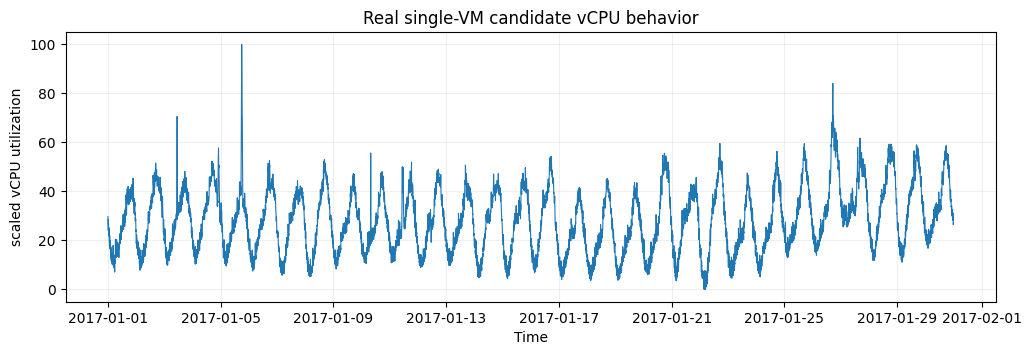

In [73]:
# Plot complete VM behavior
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(data.index, data["avg_cpu"], linewidth=0.8)
ax.set_title("Real single-VM candidate vCPU behavior")
ax.set_xlabel("Time")
ax.set_ylabel("scaled vCPU utilization")
ax.grid(alpha=0.2)
plt.show()


In [74]:
# Chronological Train / Calibration / Test split
n = len(data)
train_end = int(n * 0.70)
cal_end = int(n * 0.85)

data_train = data.iloc[:train_end].copy()
data_cal   = data.iloc[train_end:cal_end].copy()
data_test  = data.iloc[cal_end:].copy()

print(f"Train       : {data_train.index.min()} --- {data_train.index.max()}  (n={len(data_train)})")
print(f"Calibration : {data_cal.index.min()} --- {data_cal.index.max()}  (n={len(data_cal)})")
print(f"Test        : {data_test.index.min()} --- {data_test.index.max()}  (n={len(data_test)})")

assert len(data_train) > 169, "Training set is too short for the selected lags."
assert len(data_cal) > 0 and len(data_test) > 0


Train       : 2017-01-01 00:00:00 --- 2017-01-21 23:55:00  (n=6048)
Calibration : 2017-01-22 00:00:00 --- 2017-01-26 11:55:00  (n=1296)
Test        : 2017-01-26 12:00:00 --- 2017-01-30 23:55:00  (n=1296)


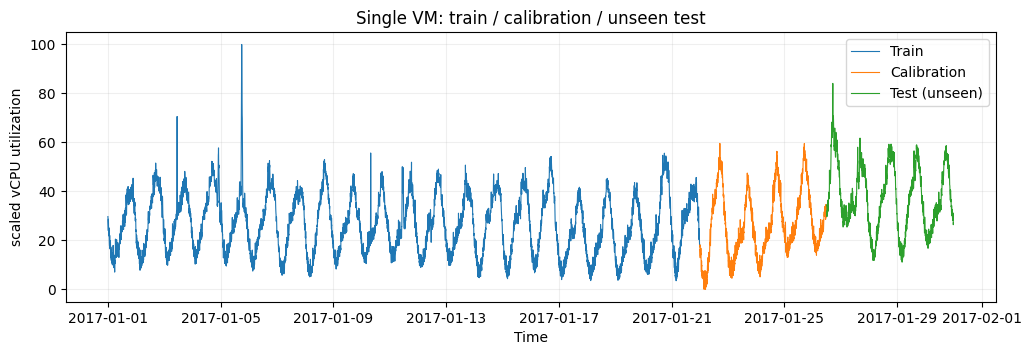

In [75]:
# Plot chronological partitions
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(data_train.index, data_train["avg_cpu"], label="Train", linewidth=0.8)
ax.plot(data_cal.index, data_cal["avg_cpu"], label="Calibration", linewidth=0.8)
ax.plot(data_test.index, data_test["avg_cpu"], label="Test (unseen)", linewidth=0.8)
ax.set_title("Single VM: train / calibration / unseen test")
ax.set_xlabel("Time")
ax.set_ylabel("scaled vCPU utilization")
ax.legend()
ax.grid(alpha=0.2)
plt.show()


In [76]:
# Forecasting model
params = {
    "max_depth": 4,
    "n_estimators": 50,
    "verbose": -1,
    "random_state": 15926
}

# Hourly trace: immediate, daily and weekly lags
lags = [1, 2, 3, 23, 24, 25, 167, 168, 169]

forecaster = ForecasterRecursive(
    LGBMRegressor(**params),
    lags=lags
)
forecaster


=================== 
ForecasterRecursive 
=================== 
Estimator: LGBMRegressor 
Lags: [  1   2   3  23  24  25 167 168 169] 
Window features: None 
Calendar features: None 
Window size: 169 
Series name: None 
Exogenous included: False 
Exogenous names: None 
Categorical features: auto 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Drop NaN from series: False 
Training range: None 
Training index type: None 
Training index frequency: None 
Estimator parameters: 
    {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0,
    'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': 4,
    'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0,
    'n_estimators': 50, 'n_jobs': None, 'num_leaves': 31, 'objective': None,
    'random_state': 15926, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample':
    1.0, 'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1} 
fit_kwargs: {} 
Creation date: 2026-10-07 11:53:29 
Last fit date: None 
Skforecast version: 0.25.0 
Python version: 3.13.16 
Forecaster id: None

## 1. Original intervals on the calibration period

The model initially sees only the **training** observations. Backtesting generates forecasts and bootstrap intervals over the calibration period. The conformal calibrator learns from the mismatch between these intervals and the real CPU observations.


In [77]:
# Prediction intervals for calibration data
steps_cal = min(24, len(data_cal))

cv_cal = TimeSeriesFold(
    steps=steps_cal,
    initial_train_size=len(data_train),
    refit=False
)

_, predictions_cal = backtesting_forecaster(
                                              forecaster=forecaster,
                                              y=data.loc[:data_cal.index[-1], "avg_cpu"].asfreq('5min'),
                                              cv=cv_cal,
                                              metric="mean_absolute_error",
                                              interval=[0.1, 0.9],
                                              interval_method="bootstrapping",
                                              n_boot=150,
                                              use_in_sample_residuals=True,
                                              use_binned_residuals=False
)

predictions_cal.head()

  0%|          | 0/54 [00:00<?, ?it/s]

,fold,pred,lower_bound,upper_bound
2017-01-22 00:00:00,0,18.385527,16.458100,20.971134
2017-01-22 00:05:00,0,17.484393,15.020673,20.644682
2017-01-22 00:10:00,0,16.743650,14.437879,20.032023
2017-01-22 00:15:00,0,16.285284,13.738386,20.643721
2017-01-22 00:20:00,0,16.053520,13.561770,20.697343


In [78]:
# Coverage before calibration on calibration data
coverage_cal_before = calculate_coverage(
    y_true=data.loc[predictions_cal.index, "avg_cpu"],
    lower_bound=predictions_cal["lower_bound"],
    upper_bound=predictions_cal["upper_bound"]
)

print("Nominal coverage target     : 80.00 %")
print(f"Calibration coverage BEFORE : {100 * coverage_cal_before:.2f} %")


Nominal coverage target     : 80.00 %
Calibration coverage BEFORE : 63.12 %


## 2. Fit the conformal calibrator

The calibrator uses the **real CPU values in the calibration period** together with their original prediction intervals. It learns the correction required to target 80% empirical coverage.


In [79]:
# Fit ConformalIntervalCalibrator on real VM calibration observations
calibrator = ConformalIntervalCalibrator(nominal_coverage=0.8)

calibrator.fit(
    y_true=data.loc[predictions_cal.index, "avg_cpu"],
    y_pred_interval=predictions_cal[["lower_bound", "upper_bound"]]
)

calibrator


=========================== 
ConformalIntervalCalibrator 
=========================== 
Nominal coverage: 0.8 
Coverage in fit data: {'avg_cpu': 0.6311728395061729} 
Symmetric interval: True 
Symmetric correction factor: {'avg_cpu': 1.6503713258025883} 
Asymmetric correction factor lower: {'avg_cpu': 1.740802072502888} 
Asymmetric correction factor upper: {'avg_cpu': 1.401194423862588} 
Fitted series: ['avg_cpu']

In [80]:
print(calibrator)

ConformalIntervalCalibrator 
Nominal coverage: 0.8 
Coverage in fit data: {'avg_cpu': 0.6311728395061729} 
Symmetric interval: True 
Symmetric correction factor: {'avg_cpu': 1.6503713258025883} 
Asymmetric correction factor lower: {'avg_cpu': 1.740802072502888} 
Asymmetric correction factor upper: {'avg_cpu': 1.401194423862588} 
Fitted series: ['avg_cpu'] 



## 3. Evaluate on completely unseen test behavior

The forecasting model can now use observations available through the end of calibration. The conformal correction itself remains learned from the separate calibration period.


In [81]:
# Original prediction intervals on unseen TEST data
steps_test = min(24, len(data_test))

cv_test = TimeSeriesFold(
    steps=steps_test,
    initial_train_size=len(data_train) + len(data_cal),
    refit=False
)

_, predictions_test = backtesting_forecaster(
                                                forecaster=forecaster,
                                                y=data["avg_cpu"].asfreq('5min'),
                                                cv=cv_test,
                                                metric="mean_absolute_error",
                                                interval=[0.1, 0.9],
                                                interval_method="bootstrapping",
                                                n_boot=150,
                                                use_in_sample_residuals=True,
                                                use_binned_residuals=False
)

predictions_test.head()

  0%|          | 0/54 [00:00<?, ?it/s]

,fold,pred,lower_bound,upper_bound
2017-01-26 12:00:00,0,33.416870,31.489799,35.533968
2017-01-26 12:05:00,0,33.139759,30.564503,35.937992
2017-01-26 12:10:00,0,33.109047,30.568100,35.822470
2017-01-26 12:15:00,0,33.109047,29.581904,36.307787
2017-01-26 12:20:00,0,33.109047,29.770688,36.728655


Nominal coverage target : 80.00 %
Test coverage BEFORE    : 57.87 %
Mean interval width     : 10.248


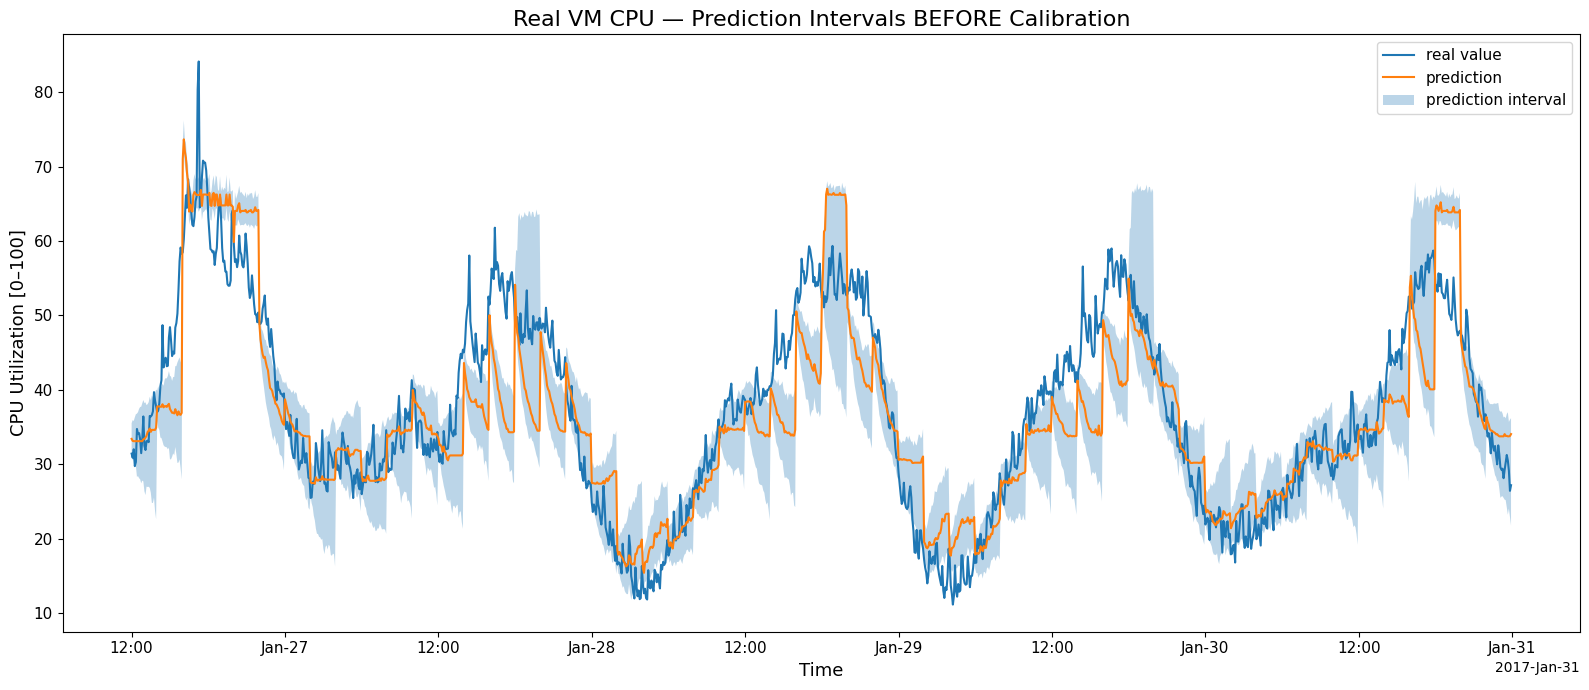

In [82]:
# BEFORE calibration: unseen test data
coverage_before = calculate_coverage(
    y_true=data.loc[predictions_test.index, "avg_cpu"],
    lower_bound=predictions_test["lower_bound"],
    upper_bound=predictions_test["upper_bound"]
)
width_before = (predictions_test["upper_bound"] - predictions_test["lower_bound"]).mean()

print("Nominal coverage target : 80.00 %")
print(f"Test coverage BEFORE    : {100 * coverage_before:.2f} %")
print(f"Mean interval width     : {width_before:.3f}")

# plot_prediction_intervals(
#     predictions=predictions_test,
#     y_true=data.loc[predictions_test.index],
#     target_variable="avg_cpu",
#     title="Real VM CPU — prediction intervals BEFORE calibration",
#     kwargs_fill_between={"alpha": 0.3, "zorder": 1}
# )

# ---------------------------------------------------------
# LARGE PLOT — BEFORE CALIBRATION
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(16, 7))

plot_prediction_intervals(
    predictions=predictions_test,
    y_true=data.loc[predictions_test.index],
    target_variable="avg_cpu",
    title="Real VM CPU — Prediction Intervals BEFORE Calibration",
    ax=ax,
    kwargs_fill_between={
        "alpha": 0.3,
        "zorder": 1
    }
)

ax.set_xlabel("Time", fontsize=13)
ax.set_ylabel("CPU Utilization [0–100]", fontsize=13)
ax.set_title(
    "Real VM CPU — Prediction Intervals BEFORE Calibration",
    fontsize=16
)

ax.tick_params(axis="both", labelsize=11)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

In [83]:
# Apply the correction learned from calibration data
predictions_test_calibrated = calibrator.transform(
    predictions_test[["lower_bound", "upper_bound"]]
)
predictions_test_calibrated["pred"] = predictions_test["pred"]
predictions_test_calibrated.head()


,level,lower_bound,upper_bound,pred
2017-01-26 12:00:00,avg_cpu,29.839427,37.184340,33.416870
2017-01-26 12:05:00,avg_cpu,28.914132,37.588363,33.139759
2017-01-26 12:10:00,avg_cpu,28.917728,37.472841,33.109047
2017-01-26 12:15:00,avg_cpu,27.931533,37.958158,33.109047
2017-01-26 12:20:00,avg_cpu,28.120316,38.379027,33.109047


Nominal coverage target : 80.00 %
Test coverage BEFORE    : 57.87 %
Test coverage AFTER     : 71.30 %
Mean width BEFORE       : 10.248
Mean width AFTER        : 13.549


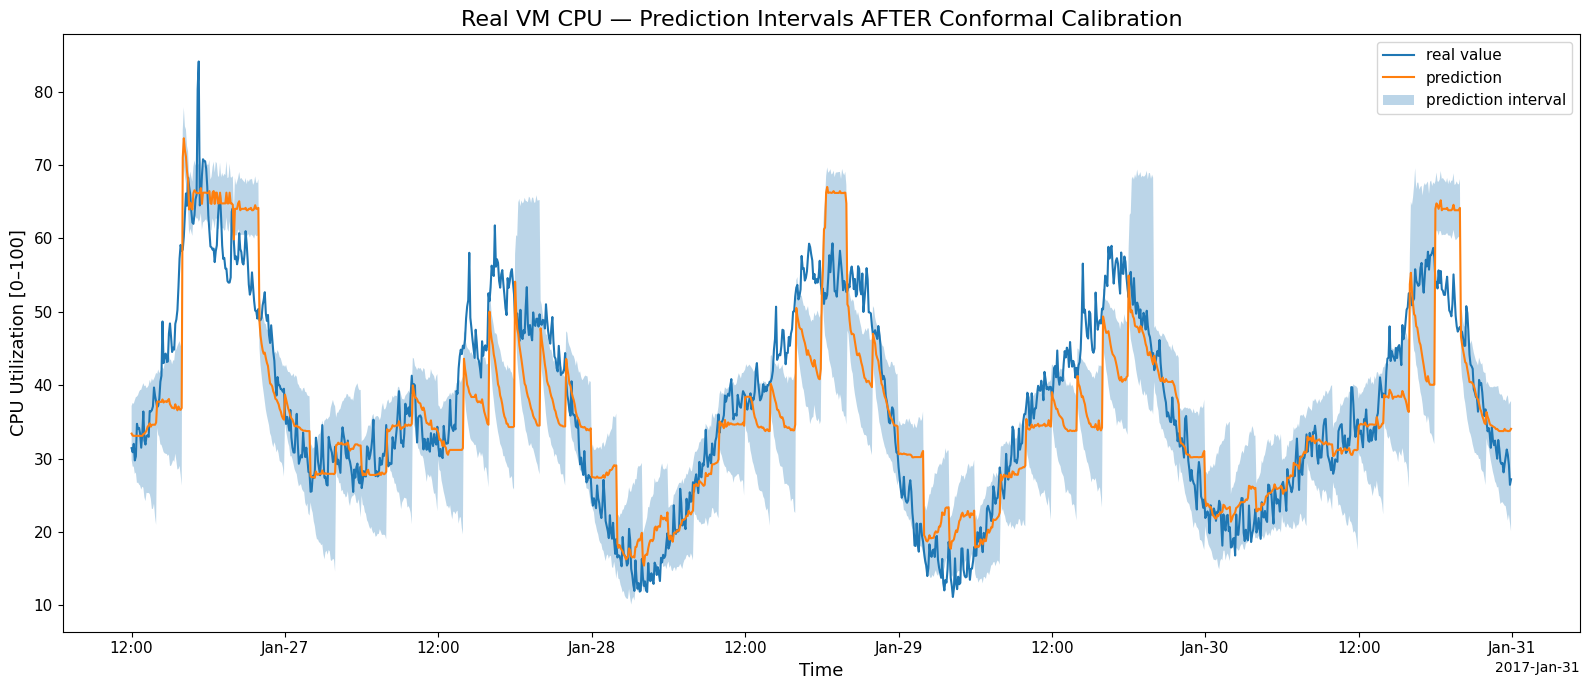

In [84]:
# AFTER conformal calibration: unseen test data
coverage_after = calculate_coverage(
    y_true=data.loc[predictions_test_calibrated.index, "avg_cpu"],
    lower_bound=predictions_test_calibrated["lower_bound"],
    upper_bound=predictions_test_calibrated["upper_bound"],
)

width_after = (
    predictions_test_calibrated["upper_bound"]
    - predictions_test_calibrated["lower_bound"]
).mean()

print("Nominal coverage target : 80.00 %")
print(f"Test coverage BEFORE    : {100 * coverage_before:.2f} %")
print(f"Test coverage AFTER     : {100 * coverage_after:.2f} %")
print(f"Mean width BEFORE       : {width_before:.3f}")
print(f"Mean width AFTER        : {width_after:.3f}")


# ---------------------------------------------------------
# LARGE PLOT
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(16, 7))

plot_prediction_intervals(
    predictions=predictions_test_calibrated,
    y_true=data.loc[predictions_test_calibrated.index],
    target_variable="avg_cpu",
    title="Real VM CPU — Prediction Intervals AFTER Conformal Calibration",
    ax=ax,
    kwargs_fill_between={
        "alpha": 0.3,
        "zorder": 1
    }
)

ax.set_xlabel("Time", fontsize=13)
ax.set_ylabel("CPU Utilization [0–100]", fontsize=13)
ax.set_title(
    "Real VM CPU — Prediction Intervals AFTER Conformal Calibration",
    fontsize=16
)

ax.tick_params(axis="both", labelsize=11)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

In [85]:
# Compact comparison
comparison = pd.DataFrame({
    "Metric": ["Coverage (%)", "Mean interval width"],
    "Before calibration": [100 * coverage_before, width_before],
    "After calibration": [100 * coverage_after, width_after]
})
comparison


,Metric,Before calibration,After calibration
0,Coverage (%),57.870370,71.296296
1,Mean interval width,10.247847,13.548590


### How to read the result

**Coverage** is the fraction of unseen CPU observations contained by the prediction interval.

With `nominal_coverage=0.8`, the target is approximately **80% coverage**. Calibration is useful when the original bootstrap intervals systematically under-cover or over-cover the real VM observations.

Also inspect **interval width**: achieving coverage by making intervals unnecessarily wide is less useful for VM right-sizing. The final test set therefore lets you compare both reliability (coverage) and sharpness (width).


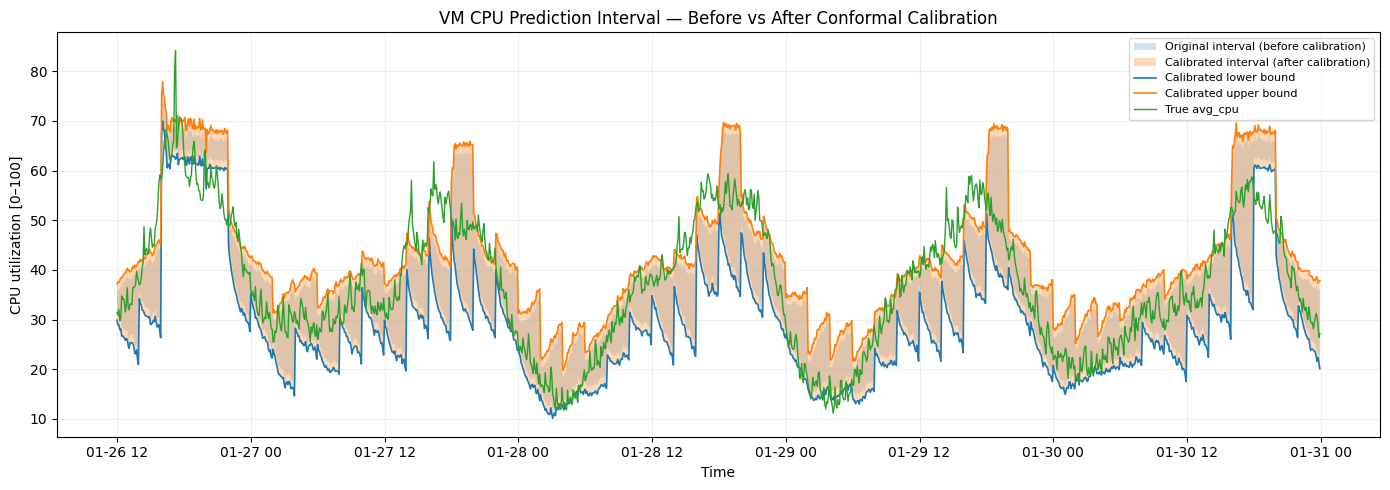

In [86]:
#-----------------------------------------------------------
# VISUALIZE BEFORE vs AFTER CALIBRATION
#-----------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 5))

x = interval.index

# Original interval BEFORE calibration
ax.fill_between(
    x,
    interval["lower_bound"],
    interval["upper_bound"],
    alpha=0.20,
    label="Original interval (before calibration)"
)

# Calibrated interval AFTER calibration
ax.fill_between(
    x,
    interval_calibrated["lower_bound"],
    interval_calibrated["upper_bound"],
    alpha=0.30,
    label="Calibrated interval (after calibration)"
)

# Calibrated boundaries
ax.plot(
    x,
    interval_calibrated["lower_bound"],
    linewidth=1.2,
    label="Calibrated lower bound"
)

ax.plot(
    x,
    interval_calibrated["upper_bound"],
    linewidth=1.2,
    label="Calibrated upper bound"
)

# True CPU
ax.plot(
    x,
    y_true,
    linewidth=1.0,
    label="True avg_cpu"
)

ax.set_title(
    "VM CPU Prediction Interval — Before vs After Conformal Calibration"
)
ax.set_xlabel("Time")
ax.set_ylabel("CPU utilization [0–100]")
ax.legend(loc="upper right", fontsize=8)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

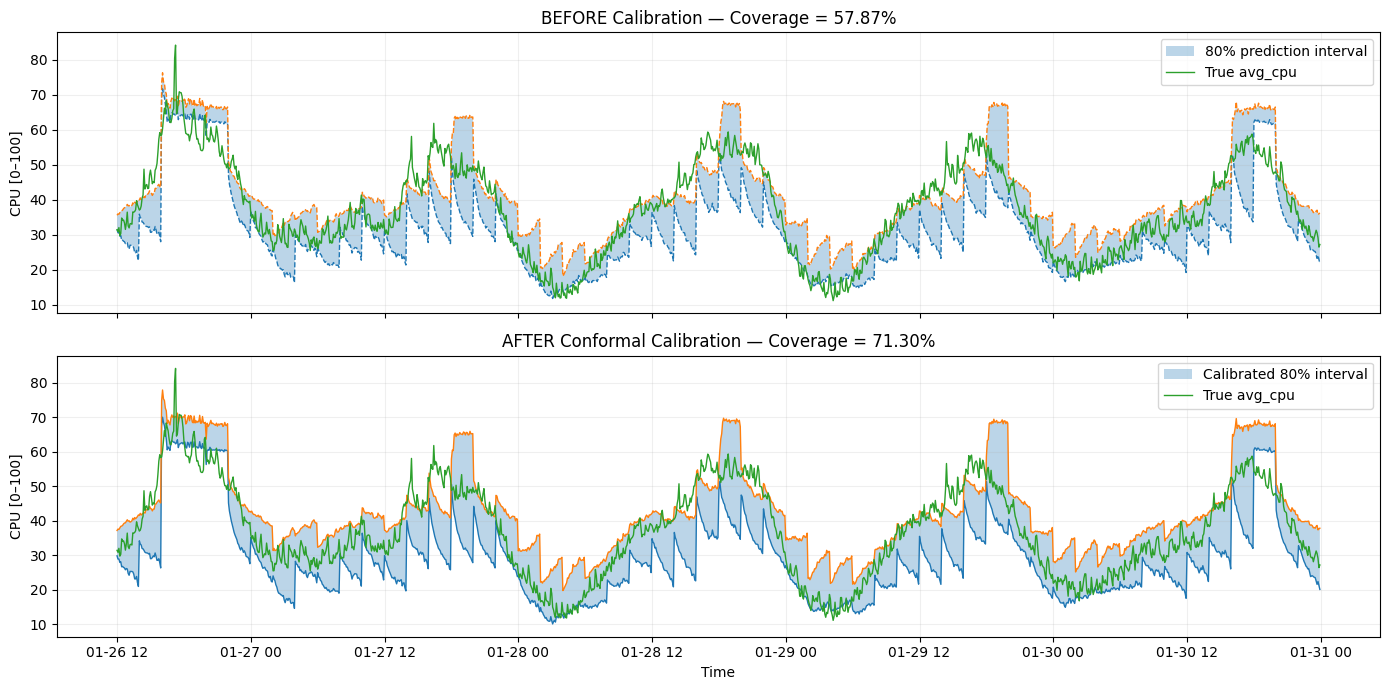

In [87]:
fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 7),
    sharex=True
)

# =========================================================
# BEFORE CALIBRATION
# =========================================================
axes[0].fill_between(
    interval.index,
    interval["lower_bound"],
    interval["upper_bound"],
    alpha=0.30,
    label="80% prediction interval"
)

axes[0].plot(
    interval.index,
    interval["lower_bound"],
    linestyle="--",
    linewidth=1
)

axes[0].plot(
    interval.index,
    interval["upper_bound"],
    linestyle="--",
    linewidth=1
)

axes[0].plot(
    y_true.index,
    y_true,
    linewidth=1,
    label="True avg_cpu"
)

axes[0].set_title(
    f"BEFORE Calibration — Coverage = {coverage_before*100:.2f}%"
)

axes[0].set_ylabel("CPU [0–100]")
axes[0].legend()
axes[0].grid(alpha=0.2)


# =========================================================
# AFTER CALIBRATION
# =========================================================
axes[1].fill_between(
    interval_calibrated.index,
    interval_calibrated["lower_bound"],
    interval_calibrated["upper_bound"],
    alpha=0.30,
    label="Calibrated 80% interval"
)

axes[1].plot(
    interval_calibrated.index,
    interval_calibrated["lower_bound"],
    linewidth=1
)

axes[1].plot(
    interval_calibrated.index,
    interval_calibrated["upper_bound"],
    linewidth=1
)

axes[1].plot(
    y_true.index,
    y_true,
    linewidth=1,
    label="True avg_cpu"
)

axes[1].set_title(
    f"AFTER Conformal Calibration — Coverage = {coverage_after*100:.2f}%"
)

axes[1].set_xlabel("Time")
axes[1].set_ylabel("CPU [0–100]")
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [88]:
#-----------------------------------------------------------
# COVERAGE BEFORE vs AFTER CALIBRATION
#-----------------------------------------------------------

coverage_before = calculate_coverage(
    y_true=y_true,
    lower_bound=interval["lower_bound"],
    upper_bound=interval["upper_bound"]
)

coverage_after = calculate_coverage(
    y_true=y_true,
    lower_bound=interval_calibrated["lower_bound"],
    upper_bound=interval_calibrated["upper_bound"]
)

print(f"Nominal coverage : 80.00%")
print(f"Before calibration: {100 * coverage_before:.2f}%")
print(f"After calibration : {100 * coverage_after:.2f}%")

Nominal coverage : 80.00%
Before calibration: 57.87%
After calibration : 71.30%


In [89]:
coverage = calculate_coverage(
               y_true      = y_true,
               lower_bound = interval_calibrated["lower_bound"],
               upper_bound = interval_calibrated["upper_bound"],
           )
print(f"Coverage after calibration: {coverage:.2f}")

Coverage after calibration: 0.71
